<a href="https://colab.research.google.com/github/Glockrover/LearnTensorFlow/blob/main/Neural_Network_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Regression with Neural Networks in TensorFlow

There are many definitions for a regression problem but in our case, we're going to simplify it: predicting a numerical variable based on some other combination of variables, even shorter... predicting a number.

In [1]:
# Import TensorFlow

import tensorflow as tf
print(tf.__version__)

2.19.0


In [2]:
## Creating data to view and fit

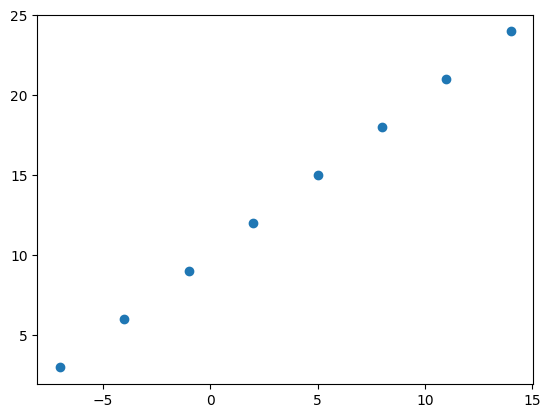

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Create features
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X,y)

In [4]:
y == X + 10

array([ True,  True,  True,  True,  True,  True,  True,  True])

In [5]:
## Input and output shapes

In [6]:
# Create a demo tensor for our housing price prediction problem
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [7]:
X[0], y[0]

(np.float64(-7.0), np.float64(3.0))

In [8]:
X[1], y[1]

(np.float64(-4.0), np.float64(6.0))

In [9]:
input_shape = X.shape
output_shape = y.shape
input_shape, output_shape

((8,), (8,))

In [10]:
# Turn NumPy arrays into tensors

X = tf.constant(X)
y = tf.constant(y)
X, y

(<tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

In [11]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape

(TensorShape([]), TensorShape([]))

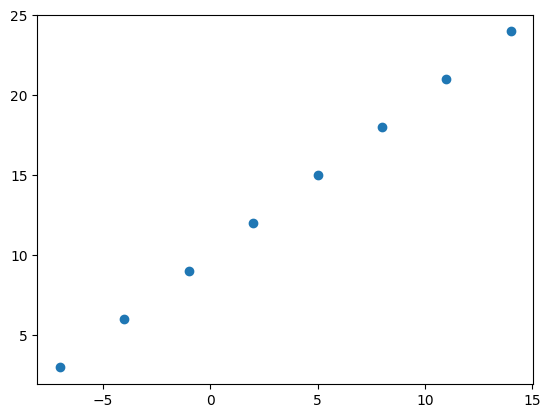

In [12]:
plt.scatter(X, y)

## Steps in modelling with TensorFlow

1. **Creating a model** - define the input and output layers, as well as the hidden layers of a deep learning model, as well as the hidden layers of deep learning model.
2. **Compiling a model** - defind the loss function (in other words, the function which tells our model how wrong it is) and the optimizer (tells our model how to imporve the patterns it's learning) and evaluation metrics (What we can use to interpret the performance of our model).
3. **Fitting a model** - letting the model try to find patterns between X & y (features and labels).

In [13]:
import tensorflow as tf

# Set random seed
tf.random.set_seed(42)

# 1. Create a model using the Sequencial API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)

])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# Make sure X has the right shape (add an extra dimension for features)
X = tf.expand_dims(X, axis=-1)

# 3. Fit the model
model.fit(X, y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step - loss: 11.1332 - mae: 11.1332
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 11.0007 - mae: 11.0007
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 10.8682 - mae: 10.8682
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 10.7357 - mae: 10.7357
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 10.6032 - mae: 10.6032


In [14]:
# Check out X and y
X, y

(<tf.Tensor: shape=(8, 1), dtype=float64, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

In [15]:
# Try and make a prediction using our model
y_pred = model.predict(tf.constant([[17.0]]))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


array([[14.520796]], dtype=float32)

In [16]:
y_pred + 12.9587

array([[27.479496]], dtype=float32)

# Improving our model

We can improve our model, by altering the steps we took to create a model.

1. **Creating a model** - here we might add more layers, increase the number of hidding units (all called neurons) within each of the hiden layers, change the activation function of each layer.

2. **Compiling a model** - here we might change the optimization function or perhaps the **learning rate** of the optimization function.

3. **Fitting a model** - here we might fit a model for more **epochs**(leaving it training for longer) or on more data (give the model more examples to learn from ).

In [17]:


model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])


model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])


model.fit(X, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - loss: 14.0741 - mae: 14.0741
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 13.9416 - mae: 13.9416
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 13.8091 - mae: 13.8091
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 13.6766 - mae: 13.6766
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 13.5441 - mae: 13.5441
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 13.4116 - mae: 13.4116
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 13.2791 - mae: 13.2791
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 13.1466 - mae: 13.1466
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 13.0141 - mae: 13.0141
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 12.8816 - mae: 12.8816
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 12.7491 - mae: 12.7491
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 12.6166 - mae: 12.6166
Epoch 13/100
1/1 ━━━━

In [18]:
X, y

(<tf.Tensor: shape=(8, 1), dtype=float64, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

In [19]:
model.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


array([[29.628922]], dtype=float32)

In [20]:
# Let's see if we can make another change to improve our model

# 1. Create the model (this time with an extra hidden layer with 100 hidden units)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation=None),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=["mae"])

# 3. Fit the model

model.fit(X, y, epochs=100)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 13.9792 - mae: 13.9792
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 13.0020 - mae: 13.0020
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - loss: 12.0226 - mae: 12.0226
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - loss: 11.0370 - mae: 11.0370
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 10.0398 - mae: 10.0398
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - loss: 9.0238 - mae: 9.0238
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - loss: 7.9814 - mae: 7.9814
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - loss: 6.9056 - mae: 6.9056
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - loss: 6.9570 - mae: 6.9570
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - loss: 7.4193 - mae: 7.4193
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 7.9823 - mae: 7.9823
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 8.1214 - mae: 8.1214
Epoch 13/100
1/1 ━━━━━━━━━━━━━

In [21]:
model.predict(tf.constant([[17]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


array([[27.422403]], dtype=float32)

## Evaulating a model

In practice, a typical workflow you'll go through when builing a neural network is :

```
Build a model -> fit it -> evaluate it -> tweak the model -> fit it -> evaluate it -> tweak the model -> fit it -> evaluate it ...
```

When it comes to evaluation... there are 3 words you should memorize: `"Visualize, visualize, visualize"`

It's a good idea to visualize:

* The data - what data are we working with? What does it look like?
* The model itself - what does our model look like?
* The training of a model - how does the model perform while it learns?
* The predictions of the model - how do the predictions of a model line up against ground truth(the original labels)?


In [22]:
# Make a bigger dataset
X = tf.range(-100, 100, 4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [23]:
# Make labels for the dataset
y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

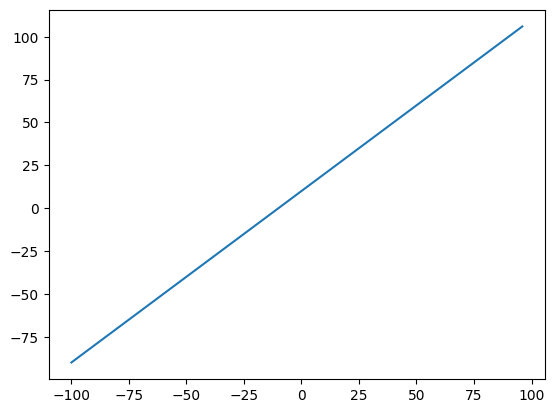

In [24]:
# Visualize the data
import matplotlib.pyplot as plt
plt.plot(X, y)

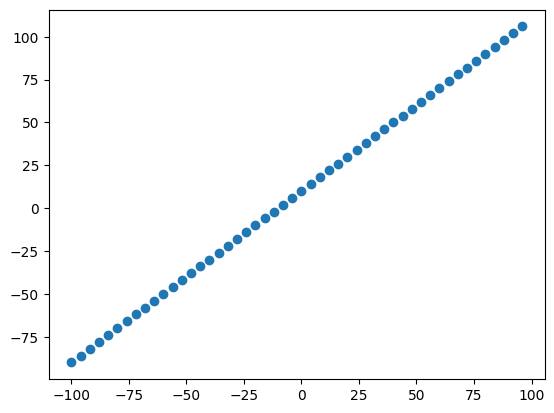

In [25]:
plt.scatter(X, y)

### The 3 sets...

* Training set - the model learns from this data, which is typically 70-80 % the total data you have available.
* Validation set - the model gets tuned on this data, which is typeically 10-15% of the data available.
* Test set - the model gets evaluated on this data to test what it has learned, this set is typically 1--15% of the total data set available.

In [26]:
# Check the length of how many samples we have
len(X)

50

In [27]:
# Split the data into train and test sets
X_train = X[:40] # first 40 are training samples (80% of the data)
y_train = y[:40]

X_test = X[40:] # last 10 are testing samples (20% of the data)
y_test = y[40:]

len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

### Visualizing the data

Now we've got our data in training and test sets... let's visualize it again!

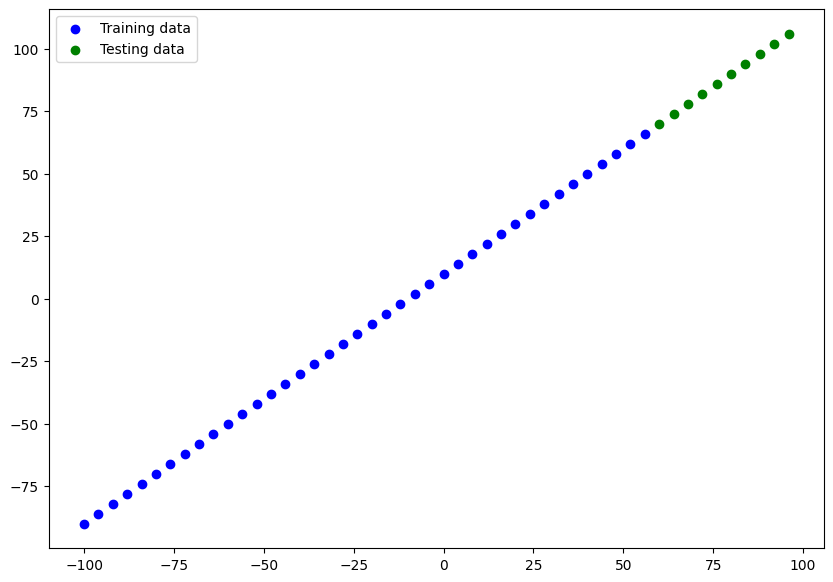

In [28]:
plt.figure(figsize=(10, 7))
# Plot training data in blue
plt.scatter(X_train, y_train, c="b", label="Training data")
# Plot test data in green
plt.scatter(X_test, y_test, c="g", label="Testing data")
# Show the legend
plt.legend()

In [29]:
# Let's have a look at how to build a neural network for our data

# 1. Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1]) # Changed to 1 output unit
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"]
              )

# 3. Fitting the model
model.fit(X_train, y_train, epochs=5)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 19.0795 - mae: 19.0795 
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 10.4685 - mae: 10.4685
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.1584 - mae: 8.1584
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9.7856 - mae: 9.7856
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 8.1397 - mae: 8.1397


In [30]:
# Visualizing the model

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

* Total params - total number of parameters in the model.
* Trainable params - these are the parameters (patterns) the model can update as it trains.
* Non-trainable params - these parameters aren't updated during training (this is typical when you bring in already learn patterns or parameters from other models during **transfer learning**)

**Resource:** for more in-depth overview of the trainable parameters within a layer, check out MIT's introduction to deep learning video.

**Exercise:** Try playing around with the number of hidden units in the dense layer, see how that affects the number of parameters (total and trainable) by calling `model.summary()`


In [31]:
# Get a summary of our model
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [32]:
# Define a new model with 10 units in the Dense layer
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1])
])

# Compile the model (using the same settings as before)
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

In [33]:

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20 (80.00 B)

 Trainable params: 20 (80.00 B)

 Non-trainable params: 0 (0.00 B)

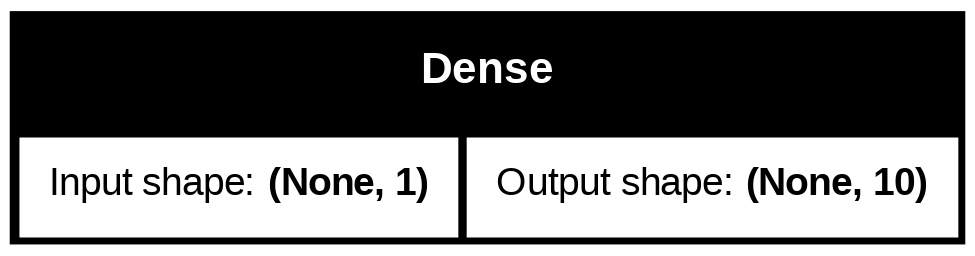

In [34]:
from tensorflow.keras.utils import plot_model

plot_model(model=model, show_shapes=True)

### Visualizing model's predictions

To visualize predctions, it's a good idea to plot them against the ground truth labels.

Oftern you'll see this in the form of y_test or y_true versus y_pred (ground truth versus your model's predictions).

In [35]:
# Make some predictions

y_pred = model.predict(X_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


array([[ 26.01007   ,   0.4045236 ,  44.02209   ,  40.999763  ,
         -9.56921   ,  26.037838  , -11.217195  ,  17.940727  ,
        -25.509363  ,  26.847971  ],
       [ 27.744076  ,   0.43149185,  46.956898  ,  43.73308   ,
        -10.207157  ,  27.773693  , -11.965008  ,  19.136776  ,
        -27.209988  ,  28.637836  ],
       [ 29.47808   ,   0.4584601 ,  49.891705  ,  46.4664    ,
        -10.845104  ,  29.509548  , -12.712821  ,  20.332825  ,
        -28.910612  ,  30.427702  ],
       [ 31.212086  ,   0.48542833,  52.82651   ,  49.19972   ,
        -11.483051  ,  31.245405  , -13.460634  ,  21.528873  ,
        -30.611237  ,  32.217567  ],
       [ 32.94609   ,   0.5123966 ,  55.761314  ,  51.933033  ,
        -12.120999  ,  32.981262  , -14.2084465 ,  22.724922  ,
        -32.31186   ,  34.00743   ],
       [ 34.680096  ,   0.5393648 ,  58.69612   ,  54.66635   ,
        -12.758946  ,  34.717117  , -14.95626   ,  23.92097   ,
        -34.012486  ,  35.797295  ],
       [ 3

In [36]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

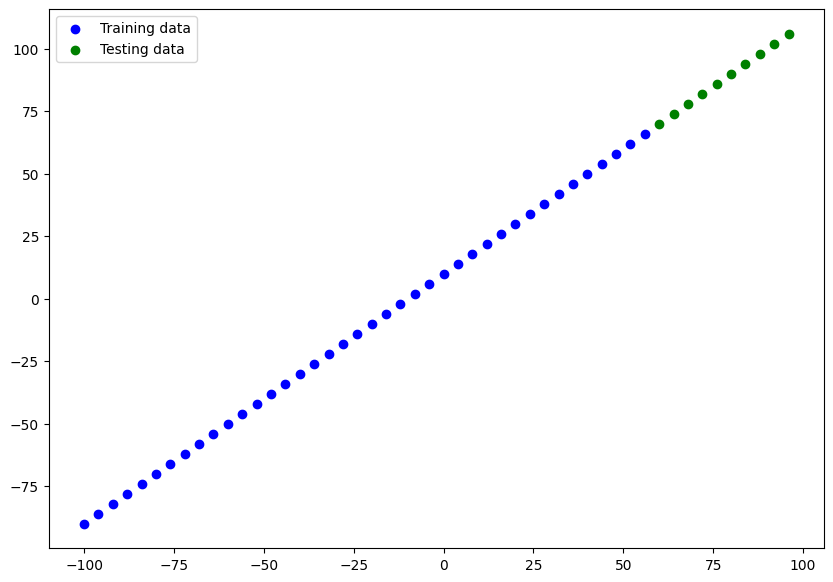

In [37]:
# Let's create a plotting function
def plot_predictions(train_data=X_train,
                   train_labels=y_train,
                     test_data = X_test,
                     test_labels=y_test,
                     predictions=y_pred):
  """
  Plots training data, test data and compareds predictions to ground truth
  """
  plt.figure(figsize=(10, 7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  # Plot testing data in green
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  # Plot the predictions in
  # plt.scatter(test_data, predictions, c="r", label="Predictions")
  # Show the legend
  plt.legend();

plot_predictions()

### Evaluating our model's predictions with regression evaluating metrics

Depending on the problem you're workink on, ther ill be different evaluation metrics to evaluate your model's performance.

Since we're working on a regression problem, two of the main metrics:

* MAE - mean absolute error, "on avarage, how wrong is each of my model's predictions"
* MSE - mean square error, "square the average errors"

In [38]:
# Evaluate the model on the test set...
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - loss: 70.3243 - mae: 70.3243


[70.32425689697266, 70.32425689697266]

In [39]:
# Calculate the mean absolute error
tf.keras.losses.mae(y_test, y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([74.403275, 73.496826, 72.590385, 71.68394 , 70.77749 , 69.87103 ,
       68.964584, 68.05814 , 67.15169 , 66.24525 ], dtype=float32)>

## Saving our models

Saving our models allows us to use thme outside of Google Colab (or wherever they were trained) such as in web application or mobile app.

There are two main formats we can save our model's too:

1. The SavedModel format
2. The HDF5 format

In [40]:
# Save model
model.save("best_model_SavedModel_format.h5")

![image](https://stmorse.github.io/images/toy_nn.png)

In [41]:
## Loadiing in a saved model

new_model = tf.keras.models.load_model("best_model_SavedModel_format.h5")
new_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 20 (80.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## Download a model(or anyy other file) from Google Colab

If you want to download your files from Google Colab:

1. You can go to the "fiels" tab and right click on the file you're after and click "download".
2. Use code (see the cell below).
3. Save it to Google Drive by conneting to Google Drive and copying it there.

In [42]:
# Download a file from Google Colab
from google.colab import files
files.download("best_model_SavedModel_format.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## A larger example

In [43]:
# Import required libraries
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [44]:
# Read in the insurance dataset
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [45]:

insurance_onehot = pd.get_dummies(insurance)
insurance_onehot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [46]:
try:
    X = insurance_onehot.drop('charges', axis=1)
    y = insurance_onehot["charges"]
    print("Successfully split data into X and y.")
    display(X.head())
    display(y.head())
except KeyError as e:
    print(f"Error: {e}. The 'charges' column was not found in the DataFrame. Please check the `insurance_onehot` DataFrame for its columns.")
    print("Current columns in insurance_onehot:", insurance_onehot.columns.tolist())
    X = None
    y = None

Successfully split data into X and y.


,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [47]:
# Create training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


In [48]:
len(X_test), len(X_train), len(y_test), len(y_train)

(268, 1070, 268, 1070)

In [49]:
# Build a neural network

insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.SGD(),
                        metrics=["mae"])

insurance_model.fit(X_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8557.7480 - mae: 8557.7480  
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7539.3882 - mae: 7539.3882
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7514.4824 - mae: 7514.4824
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7542.8955 - mae: 7542.8955
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7572.8804 - mae: 7572.8804
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7525.3403 - mae: 7525.3403
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7752.5273 - mae: 7752.5273
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7733.2471 - mae: 7733.2471
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7624.0825 - mae: 7624.0825
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7684.3159 - mae: 7684.3159
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7728.2671 - mae: 7728.2671
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

In [50]:
insurance_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7559.1128 - mae: 7559.1128  


[7559.11279296875, 7559.11279296875]

In [51]:
y_preds = insurance_model.predict(X_test)
y_preds.mean() , y_test.mean()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


(np.float32(5409.2046), np.float64(12968.317062869404))

Right now it looks like our model isn't performing too well... let's try and improve it!

To try improve our model, we'll run 2 experiments:

1. Add an extra layer with more hidden units
2. Train for longer
3. (insert your own experiments here)

In [52]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model

insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(50),
    # tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)])

# 2. Compile the model
insurance_model_2.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.SGD(),
                          metrics=["mae"])

# 3. Fit the model
insurance_model_2.fit(X_train, y_train, epochs=200, verbose=0)

In [53]:
# Evaluate the larger model
insurance_model_2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5921.7324 - mae: 5921.7324  


[5921.732421875, 5921.732421875]

In [54]:
insurance_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7559.1128 - mae: 7559.1128 


[7559.11279296875, 7559.11279296875]

In [59]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed
tf.random.set_seed(42)

# 1. Create a model
insurance_model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model

insurance_model_3.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=["mae"])

# 3. Fit the model
history = insurance_model_3.fit(X_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13284.2217 - mae: 13284.2217
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13098.9463 - mae: 13098.9463
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12726.9736 - mae: 12726.9736
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12018.5166 - mae: 12018.5166
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10859.6523 - mae: 10859.6523
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9418.8516 - mae: 9418.8516
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8107.2271 - mae: 8107.2271
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7503.7080 - mae: 7503.7080
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7416.9292 - mae: 7416.9292
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7393.2754 - mae: 7393.2754
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7372.2612 - mae: 7372.2612
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s

In [60]:
insurance_model_3.evaluate(X_test, y_test)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4606.1411 - mae: 4606.1411  


[4606.14111328125, 4606.14111328125]

Text(0.5, 0, 'epochs')

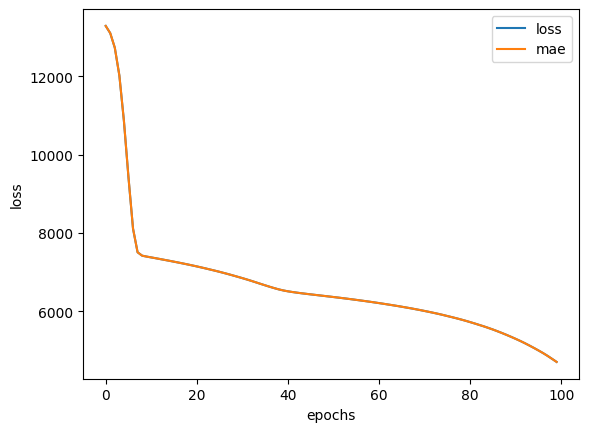

In [61]:
# Plot history (also know as a loss curve or a training curve)
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")

## Preprocessing data (normalization and standardization)

<Axes: ylabel='Frequency'>

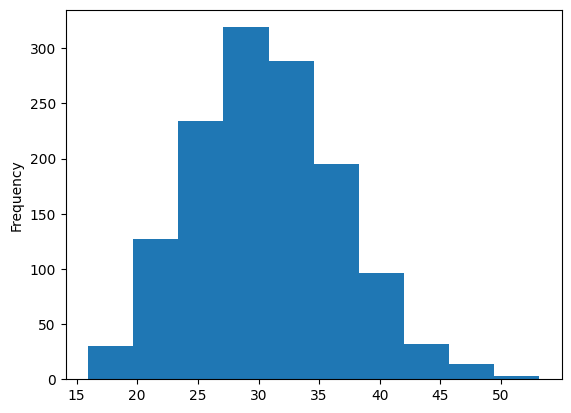

In [62]:
X["bmi"].plot(kind="hist")

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Read the insurance csv
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


To prepare our data, we can borrow a few classes from Scikit-Learn


In [65]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Create a column transformer
ct = make_column_transformer(
    (MinMaxScaler(), ["age", "bmi", "children"]), # get all values between 0 and 1
    (OneHotEncoder(handle_unknown="ignore"), ["sex", "smoker", "region"])
)

# Create X & y values

X = insurance.drop("charges", axis=1)
y = insurance["charges"]

# Build our train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# Fit the column transformer to our training data
ct.fit(X_train)

# Transform training and test data with normalization (MinMazScala) and OneHotEncoder
X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)



In [66]:
# What does our data look like now?

X_train.loc[0]

,0
age,19
sex,female
bmi,27.9
children,0
smoker,yes
region,southwest


In [68]:
X_train_normal[0]

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

In [69]:
X_train.shape, X_train_normal.shape

((1070, 6), (1070, 11))

In [71]:
# Build a neural network to fit on our normalized data

tf.random.set_seed(42)

# 1. Create the model
insurance_model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model_4.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=["mae"]
)

# 3. Fit the model
insurance_model_4.fit(X_train_normal, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 13342.8184 - mae: 13342.8184
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13331.8730 - mae: 13331.8730
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13305.3779 - mae: 13305.3779
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13251.1885 - mae: 13251.1885
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13158.1992 - mae: 13158.1992
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13016.0693 - mae: 13016.0693
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12814.6416 - mae: 12814.6416
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12544.0156 - mae: 12544.0156
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12194.8447 - mae: 12194.8447
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11765.5107 - mae: 11765.5107
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11274.3701 - mae: 11274.3701
Epoch 12/100
34/34 ━━━━━━━━━━━

In [72]:
# Evaluate our insurance model trained on normalized data
insurance_model_4.evaluate(X_test_normal, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3424.6555 - mae: 3424.6555  


[3424.655517578125, 3424.655517578125]

In [73]:
insurance_model_4.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 100)            │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,665 (26.04 KB)

 Trainable params: 2,221 (8.68 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,444 (17.36 KB)